In [1]:
include("PermBasis.jl")
include("PlotSetup.jl")
using PyPlot

function der2(A, dx)
    return (A[3:end] .- 2 .* A[2:end-1] .+ A[1:end-2]) ./ dx^2
end

function der(A, dx)
    return (A[3:end] .- A[1:end-2]) ./ (2dx)
end

function der3(A, dx)
    return (A[5:end] .- 2 .* A[4:end-1] .+ 2 .* A[2:end-3] .- A[1:end-4]) ./ (2dx^3)
end

function meanfield_reduced!(du, u, p, t)
    I, m = u
    Γ, ξ, N, γ = p

    du[1] = (2 * N * Γ * m - ξ - γ) * I
    du[2] = -N * Γ * I - γ * (m + 0.5)
end

meanfield_reduced! (generic function with 1 method)

In [2]:
valid(s,m) = abs(m) <= s || isapprox(s, m, atol=1e-5)
mvals(N) = range(-N/2, N/2)
svals(N) = collect(0:N÷2)

function P_JM_z_minus2(J, M, N)
    if J == 0 return 0.0 end
    return (N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1))
end
A_JM_minus2(J, M) = (J + M) * (J - M + 1)
P_JM_z_plus2(J, M, N) = (N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1))

function P_JM_minus_02(J, M, N)
    if J == 0
        return 0.0
    end
    return ((2 + N) / (4 * J * (J + 1))) * A_JM_minus2(J, M)
end

function P_JM_minus_minus2(J, M, N) 
    if J == 0
        return 0.0
    end
    return ((N + 2 * J + 2) * (J + M) * (J + M - 1) / (4 * J * (2 * J + 1)))
end

P_JM_minus_plus2(J, M, N) = ((N - 2 * J) * (J - M + 1) * (J - M + 2) / (4 * (J + 1) * (2 * J + 1)))

function run_trajectory(N::Int64, Γ::Float64, ξ::Float64, γ::Float64, t_max::Float64, observable; M0::Int64 = N ÷ 2, S0::Int64 = N ÷ 2, sizehint::Int64 = 0)
    
    S::Int64 = S0
    M::Int64 = M0
    t = 0.0
    
    times::Vector{Float64} = []; sizehint!(times, sizehint)
    out::Vector{typeof(observable(S, M, N, Γ, ξ))} = []; sizehint!(out, sizehint)

    push!(times, 0.0)
    push!(out, observable(S, M, N, Γ, ξ))

    
    while t < t_max
        # 1. Calculate rates
        r_dec = Γ * A_JM_minus2(S, M) + γ * P_JM_minus_02(S, M, N)
        r_up  = ξ * P_JM_z_plus2(S, M, N)
        r_down = ξ * P_JM_z_minus2(S, M, N)
        r_dec_down = γ * P_JM_minus_minus2(S, M, N)
        r_dec_up = γ * P_JM_minus_plus2(S, M, N)
        
        r_total = r_dec + r_up + r_down + r_dec_up + r_dec_down
        
        if r_total <= 1e-10
            push!(times, t_max)
            push!(out, observable(S, M, N, Γ, ξ))
            break
        end
        

        tau = -log(rand()) / r_total        
        r_val = rand() * r_total
        
        if r_val < r_dec
            # Decay: m -> m - 1
            M -= 1
        elseif r_val < r_dec + r_up
            # Dephasing Up: s -> s + 1
            S += 1
        elseif r_val < r_dec + r_up + r_down
            # Dephasing Down: s -> s - 1
            S -= 1
        elseif r_val < r_dec + r_up + r_down + r_dec_up
            #
            S += 1
            M -= 1
        else
            #
            S -= 1
            M -= 1
        end
        
        t += tau        
        push!(times, t)
        push!(out, observable(S, M, N, Γ, ξ))
    end

    return times, out
end

function simulate_ensemble(N, Γ, ξ, γ, t_max::Float64, observable, N_traj; M0 = N ÷ 2, S0 = N ÷ 2)
    
    # Create a common time grid for averaging
    time_grid = range(0, t_max, length=1000)
    avg_obs = Vector{Any}(nothing, length(time_grid))

    for i=1:N_traj
        ts, Is= run_trajectory(N, Γ, ξ, γ, t_max, observable; M0 = M0, S0 = S0)
        
        idx = 1
        for (k, t_point) in enumerate(time_grid)
            while idx < length(ts) && ts[idx+1] < t_point
                idx += 1
            end
            if avg_obs[k] == nothing
                avg_obs[k] = Is[idx]
            else
                avg_obs[k] += Is[idx]
            end
        end
    end
    
    return time_grid, avg_obs ./ N_traj
end


simulate_ensemble (generic function with 1 method)

# Check Monte Carlo against rate equation simulation

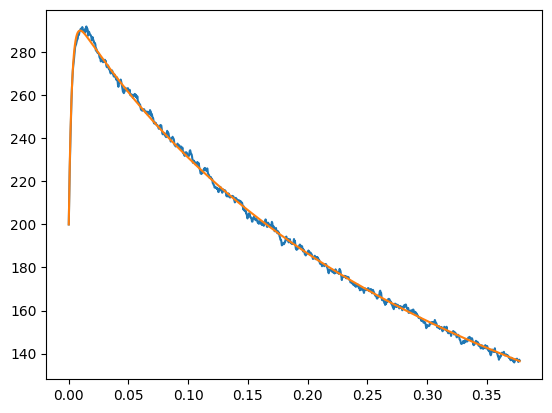

In [9]:
Jmax = 100
N = 2 * Jmax
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 3.0 * N, "local_decay" => 0.0 * N)

basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)

function f!(u, p, t)
    return Q * u
end

tmax = 2.0 / log(N)
prob = ODEProblem(f!, p0, (0.0, tmax), dt = 0.001)
sol = solve(prob, RK4())   # or Tsit5(), etc.

expval_S(state, index_mapping) = sum(state[value] * key[1] for (key,value) in index_mapping)
expval_M(state, index_mapping) = sum(state[value] * key[2] for (key,value) in index_mapping)
expval_I(state, index_mapping) = sum(state[value] * ((S+M) * (S-M+1)) for ((S,M),value) in index_mapping)
intens_rate = expval_I.(sol.u, Ref(index_mapping))
t_rate = sol.t


N_traj = 10000
s_vals = Int.(round.(svals(N)))
m_vals = Int.(round.(mvals(N)))
s_map = Dict(s_vals .=> 1:length(s_vals))
m_map = Dict(m_vals .=> 1:length(m_vals))
p_sm = zeros(length(s_vals), length(m_vals))


times_mc, intens_mc = simulate_ensemble(N, params["global_decay"], params["local_dephasing"], params["local_decay"], tmax, (S, M, N, Γ, ξ) -> (S+M) * (S-M+1), N_traj)

plot(times_mc[1:end], intens_mc[1:end])
plot(t_rate, intens_rate)
display(gcf())
close("all")


# Mean field vs Monte Carlo

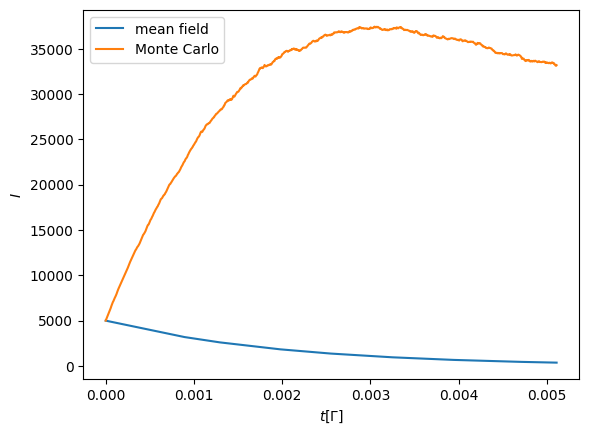

In [ ]:
function mf_vs_mf(N, param, N_traj; time_factor = 3.0)

    tmax = time_factor * log(N) / N
    s_vals = Int.(round.(svals(N)))
    m_vals = Int.(round.(mvals(N)))
    s_map = Dict(s_vals .=> 1:length(s_vals))
    m_map = Dict(m_vals .=> 1:length(m_vals))
    p_sm = zeros(length(s_vals), length(m_vals))


    times_mc, intens_mc = simulate_ensemble(N, params["global_decay"], params["local_dephasing"], params["local_decay"], tmax, (S, M, N, Γ, ξ) -> (S+M) * (S-M+1), N_traj)

    # mean field equation of motion
    p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
    u0 = [1/N, 1/2]


    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=1e-8, abstol=1e-8)
    intens_mf = map(x -> x[1], mfsol.u)


    plot(mfsol.t, intens_mf * N^2, label = "mean field")
    plot(times_mc[1:end], intens_mc[1:end], label = "Monte Carlo")
    legend()
    xlabel(L"t[\Gamma]")
    ylabel(L"I")
    display(gcf())
    close("all")
end

N = 5000
N_traj = 4000


params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 1.1 * N, "local_decay" => 0.0 * N)
mf_vs_mf(N, params, N_traj; time_factor = 3.0)

# Meaning that it tends to fail for the independent emission part, but the predictions for the maximum intensity are actually still correct

In [ ]:
function mc_vs_mf_data(N, param, N_traj; time_factor = 3.0)

    tmax = time_factor * log(N) / N
    s_vals = Int.(round.(svals(N)))
    m_vals = Int.(round.(mvals(N)))
    s_map = Dict(s_vals .=> 1:length(s_vals))
    m_map = Dict(m_vals .=> 1:length(m_vals))
    p_sm = zeros(length(s_vals), length(m_vals))


    times_mc, intens_mc = simulate_ensemble(N, params["global_decay"], params["local_dephasing"], params["local_decay"], tmax, (S, M, N, Γ, ξ) -> (S+M) * (S-M+1), N_traj)

    # mean field equation of motion
    p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
    u0 = [1/N, 1/2]


    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=1e-8, abstol=1e-8)
    intens_mf = map(x -> x[1], mfsol.u)


    return maximum(intens_mc), maximum(intens_mf)
end

N = 5000
N_traj = 4000
rs = range(0.0, 1.5, 50)
gs = range(0.0, 0.5, 50)
mf_data = zeros(length(rs), length(gs))
mc_data = zeros(length(rs), length(gs))

for (i,r) in enumerate(rs)
    for (j,g) in enumerate(gs)
        params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => r * N, "local_decay" => g * N / log(N))
        imc, imf = mc_vs_mf_data(N, params, N_traj; time_factor = 8.0)
        mf_data[i,j] = imf
        mc_data[i,j] = imc
    end
end

# You have the standard mistake that meanfield gives you 1/4 for Dicke, which is not asymptotically correct. Aside from that the result of the mean field is representative

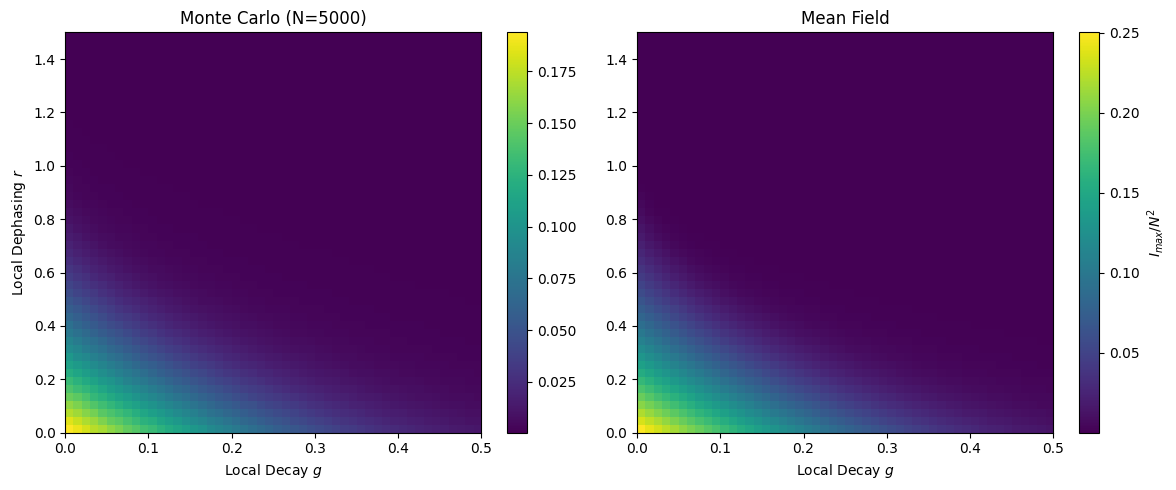

In [74]:
using PyPlot

# Define extent based on your ranges
ext = [minimum(gs), maximum(gs), minimum(rs), maximum(rs)]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Monte Carlo Plot
im1 = axs[1].imshow(mc_data / N^2, extent=ext, origin="lower", aspect="auto", cmap="viridis")
axs[1].set_title("Monte Carlo (N=$N)")
axs[1].set_xlabel(L"Local Decay $g$")
axs[1].set_ylabel(L"Local Dephasing $r$")
colorbar(im1, ax=axs[1])

# Mean Field Plot
im2 = axs[2].imshow(mf_data, extent=ext, origin="lower", aspect="auto", cmap="viridis")
axs[2].set_title("Mean Field")
axs[2].set_xlabel(L"Local Decay $g$")
colorbar(im2, ax=axs[2], label=L"I_{max} / N^2")

tight_layout()

display(gcf())
close("all")

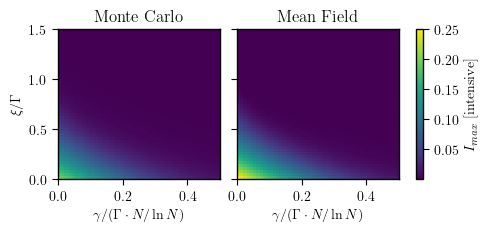

In [89]:
using PyPlot

wt, ht = latex_plot_setup()


# Normalization
mc_norm = mc_data ./ N^2
mf_norm = mf_data 

# Global limits for shared colorbar
v_min = min(minimum(mc_norm), minimum(mf_norm))
v_max = max(maximum(mc_norm), maximum(mf_norm))

# Setup figure with constrained_layout to fix colorbar placement
fig, axs = plt.subplots(1, 2, figsize = (2 * wt, 1.5 * ht), sharey=true, constrained_layout=true)
ext = [gs[1], gs[end], rs[1], rs[end]]

# Subplot 1: Monte Carlo
im1 = axs[1].imshow(mc_norm, extent=ext, origin="lower", aspect="auto", 
                    vmin=v_min, vmax=v_max, cmap="viridis")
axs[1].set_title("Monte Carlo")
axs[1].set_ylabel(L"$\xi / \Gamma$")
axs[1].set_xlabel(L"$\gamma / (\Gamma \cdot N / \ln N)$")

# Subplot 2: Mean Field
im2 = axs[2].imshow(mf_norm, extent=ext, origin="lower", aspect="auto", 
                    vmin=v_min, vmax=v_max, cmap="viridis")
axs[2].set_title("Mean Field")
axs[2].set_xlabel(L"$\gamma / (\Gamma \cdot N / \ln N)$")

# Add a single colorbar to the right of both subplots
cb = fig.colorbar(im1, ax=axs, location="right")
cb.set_label(L"$I_{max}$ [intensive]")
savefig("../data/mean_field_vs_MC.pdf", bbox_inches = "tight")
display(gcf())